R - Recency - how many days since a customer purchased  
F - Frequency how often a customer purchase - here number of purchaces  
M - Monetory - how valuable the customer - total amount he spend  

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/cleaned_data.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  int64  
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  object 
 8   Revenue      397884 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 27.3+ MB


### calculating snapshot date 

In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [6]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [7]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [8]:
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [9]:
# lambda x: (snapshot_date - max(x))
# td = pd.Timedelta("5 days 12:30:00")

# td.days      # 5

In [10]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - max(x)).days,

    "InvoiceNo" : "nunique",
    "Revenue" : "sum"
})

In [11]:
rfm.head(2)

,InvoiceDate,InvoiceNo,Revenue
CustomerID,,,
12346.0,326,1,77183.6
12347.0,2,7,4310.0


In [12]:
rfm.columns = ["Recency","Frequency","Monetary"]

In [13]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# representation of rfm

In [14]:
import matplotlib.pyplot as plt

In [15]:
rfm["Recency"].max()

np.int64(374)

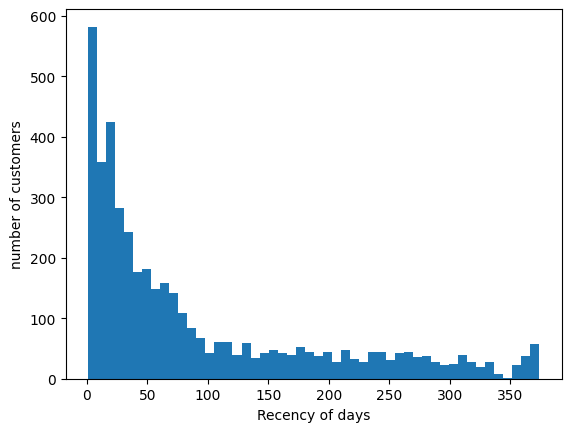

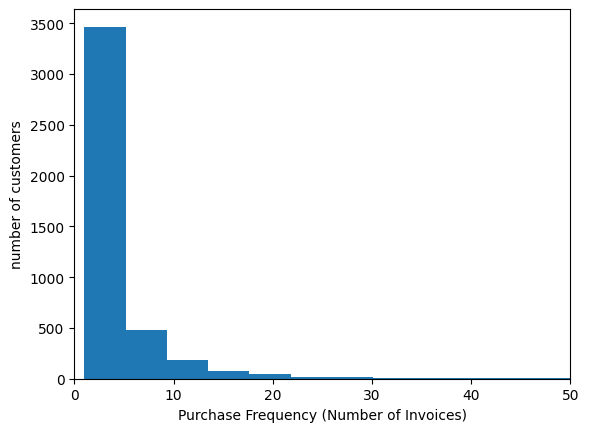

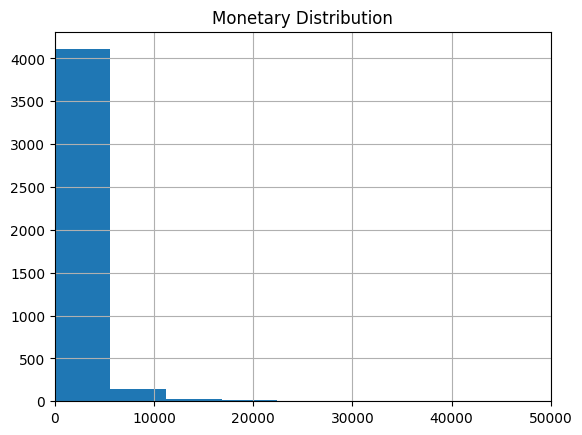

In [16]:
plt.figure()
plt.hist(rfm["Recency"], bins=50)
plt.xlabel("Recency of days")
plt.ylabel("number of customers")
plt.show()

plt.figure()
plt.hist(rfm["Frequency"], bins=50)
plt.xlim(0,50)
plt.xlabel("Purchase Frequency (Number of Invoices)")
plt.ylabel("number of customers")
plt.show()

plt.figure()
rfm["Monetary"].hist(bins=50)
plt.xlim(0,50000)
plt.title("Monetary Distribution")
plt.show()

In [17]:
avg_recency = rfm["Recency"].mean()
max_frequency = rfm["Frequency"].max()

In [18]:
print("Average Recency :",avg_recency)
print("max frequency ",max_frequency)

Average Recency : 92.53642231443061
max frequency  209


In [19]:
# rfm.to_csv("data/rfm_features.csv",index=False)
# not done because customer id is the index

In [20]:
rfm.reset_index().to_csv("data/rfm_features.csv",index=False)